<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/GAN_cnn_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [ ]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [ ]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [ ]:
### BINARY TRAJ

nb_traj = 500
length = 200
traj = np.zeros((nb_traj, length))

for i in range(nb_traj):
    l = np.random.randint(2,length/2)
    st = np.random.randint(1, length-l-1)

    traj[i,st:st+l] = 1

In [ ]:
class TrajDataSet(Dataset):
    def __init__(self,  traj, transform=None):
        
        self.traj = traj   # save trips
        self.transform = transform

    def __len__(self):
        return self.traj.shape[0]

    def __getitem__(self, idx):
        sample = traj[idx,:]
        if self.transform:
            sample = self.transform(sample)
        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""
    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [ ]:
# hyperparameters
batch_size = 100

## reduce size dataset
train_set = TrajDataSet(traj, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [ ]:
x =  next(iter(train_loader))

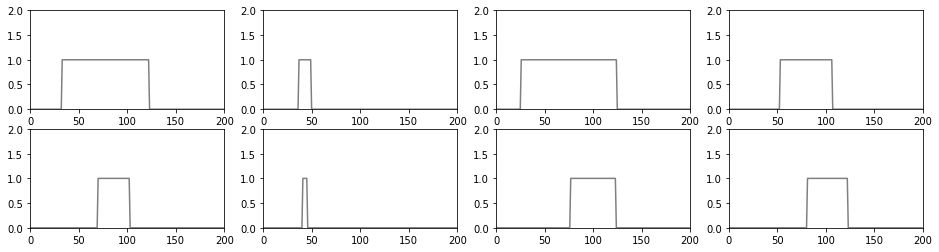

In [ ]:
plt.figure(figsize = (16,4))

for i in range(8):
  plt.subplot(2,4,i+1)
  plt.plot(x.numpy()[i,:], c = 'black', alpha = 0.5)
  plt.xlim(0,length)
  plt.ylim(0,2)


## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [ ]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

## CNN

In [ ]:
class CNNGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.cnn = nn.Sequential(    
            nn.ConvTranspose1d(32, 16, kernel_size = 50, stride = 1, padding = 0, bias = False),
            nn.BatchNorm1d(16),
            nn.ReLU(True),

            nn.ConvTranspose1d(16, 8, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(8),
            nn.ReLU(True),

            nn.ConvTranspose1d(8, 1, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.Tanh()
         )
        

    def forward(self, z):    
      out = self.cnn(z)
      return out

In [ ]:
gen = CNNGenerator()
z = torch.rand((batch_size, 32, 1)) # (batch, features, len)

out = gen(z)
out.shape

torch.Size([100, 1, 200])

In [ ]:
sum(p.numel() for p in gen.parameters())

26192

In [ ]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

                
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 8,  kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(8, 16,  kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(16, 1, kernel_size=50, stride=2, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):

        out = self.cnn(x.view((batch_size, 1, 200)))
        return out.squeeze(1)


In [ ]:
dis = CNNDiscriminator()
dis(x).shape

torch.Size([100, 1])

# training

In [ ]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = CNNGenerator().to(device)
discriminator = CNNDiscriminator().to(device)


# ### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.654637485742569, Dr : 0.9197662770748138, Df : 1.2917441874742508


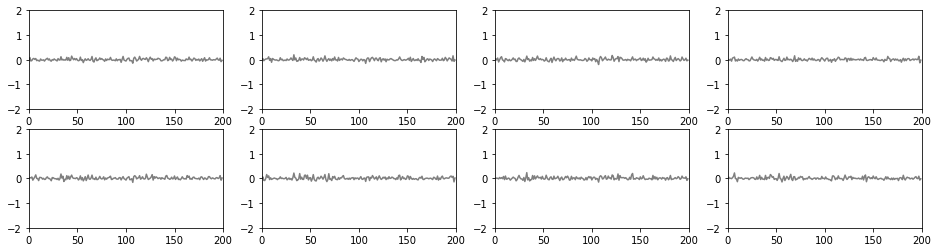

Epoch [201/5000] -----------------------------------------------------------------------------
G: 3.7103598713874817, Dr : 0.056594896130263805, Df : 0.06993681378662586


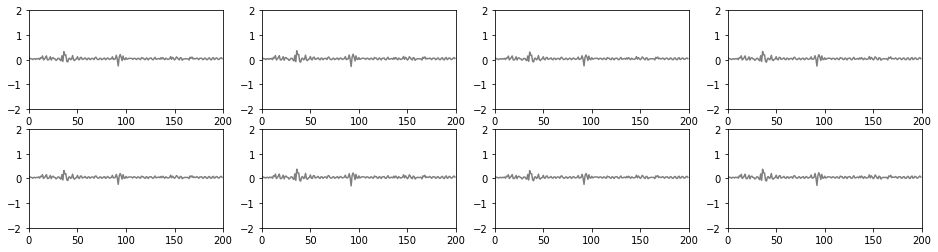

Epoch [401/5000] -----------------------------------------------------------------------------
G: 6.556602835655212, Dr : 0.006625605747103691, Df : 0.007282115984708071


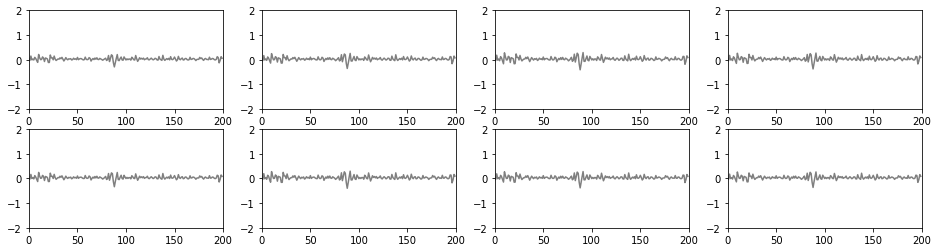

Epoch [601/5000] -----------------------------------------------------------------------------
G: 7.107369303703308, Dr : 0.0031802680459804833, Df : 0.0043233775068074465


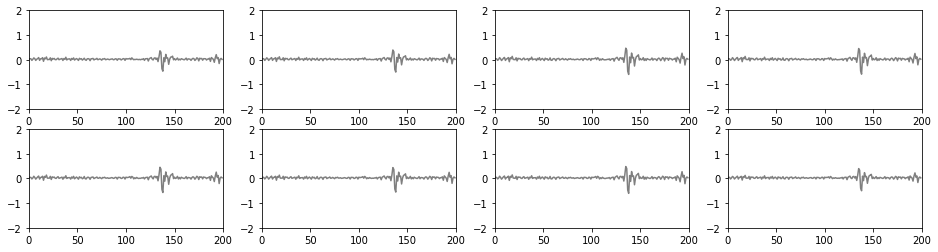

Epoch [801/5000] -----------------------------------------------------------------------------
G: 7.5919166803359985, Dr : 0.0014236703573260456, Df : 0.0030141965835355222


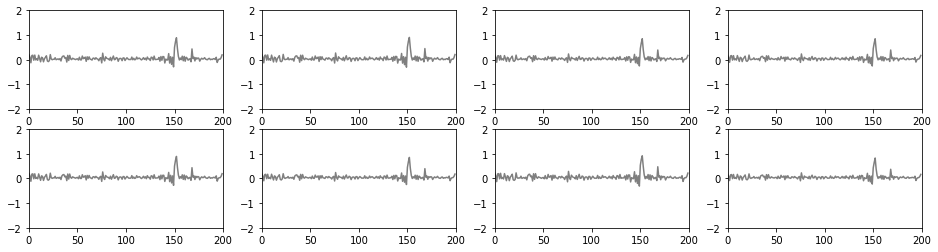

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 8.22339153289795, Dr : 0.0018903376767411828, Df : 0.0017620745638851076


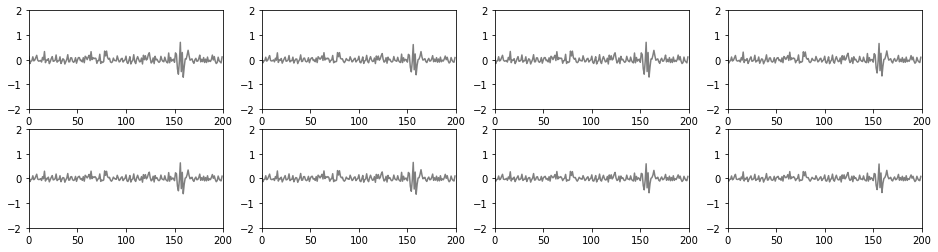

Epoch [1201/5000] -----------------------------------------------------------------------------
G: 8.643450021743774, Dr : 0.0014342664217110723, Df : 0.0012100198946427554


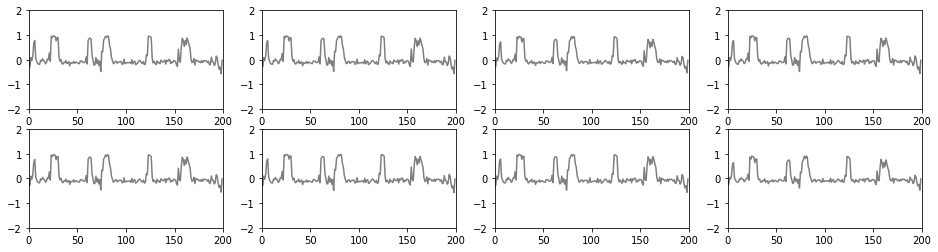

Epoch [1401/5000] -----------------------------------------------------------------------------
G: 7.4622642993927, Dr : 0.004810818412806839, Df : 0.0034867453505285084


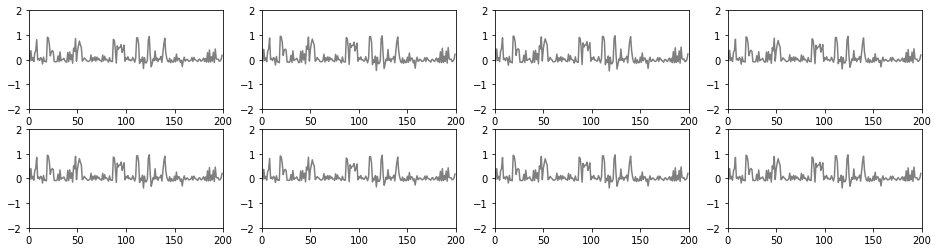

Epoch [1601/5000] -----------------------------------------------------------------------------
G: 8.158896565437317, Dr : 0.0016469665424665436, Df : 0.0019716883543878794


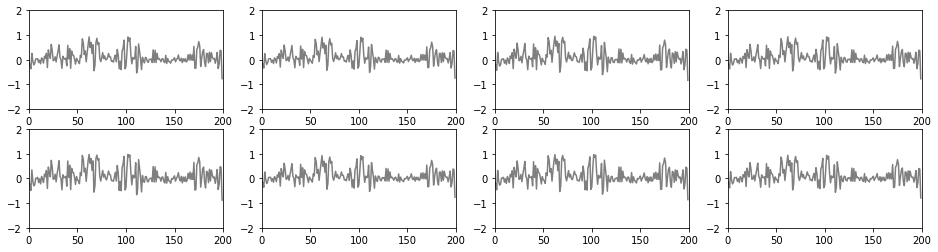

Epoch [1801/5000] -----------------------------------------------------------------------------
G: 7.458613634109497, Dr : 0.0028624217957258224, Df : 0.004181003663688898


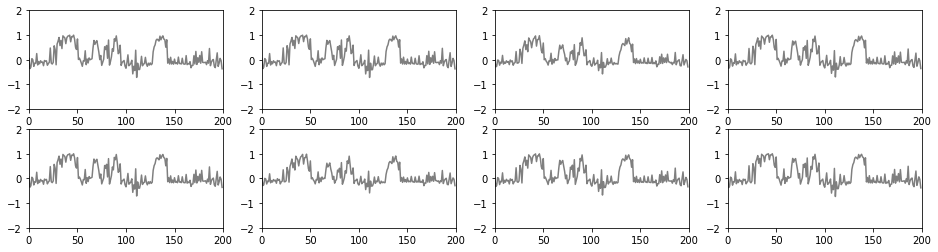

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 8.38687789440155, Dr : 0.0010596861684462056, Df : 0.0015840806590858847


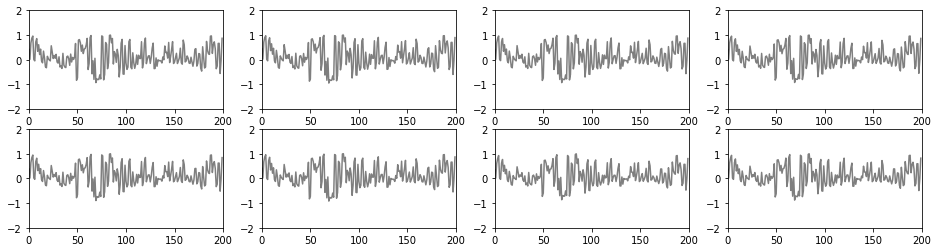

Epoch [2201/5000] -----------------------------------------------------------------------------
G: 10.630895853042603, Dr : 0.0006185563215694856, Df : 0.00025714418734423816


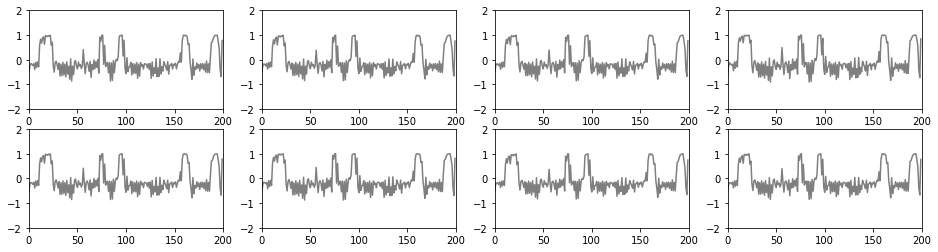

Epoch [2401/5000] -----------------------------------------------------------------------------
G: 12.269389629364014, Dr : 4.8583662646706216e-05, Df : 6.907924398547038e-05


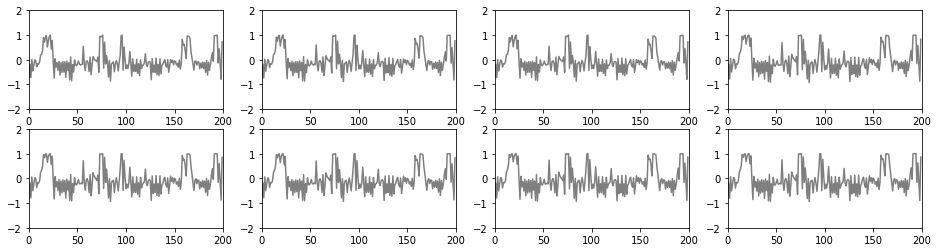

Epoch [2601/5000] -----------------------------------------------------------------------------
G: 10.244500637054443, Dr : 6.332133852993138e-05, Df : 0.00037544182123383507


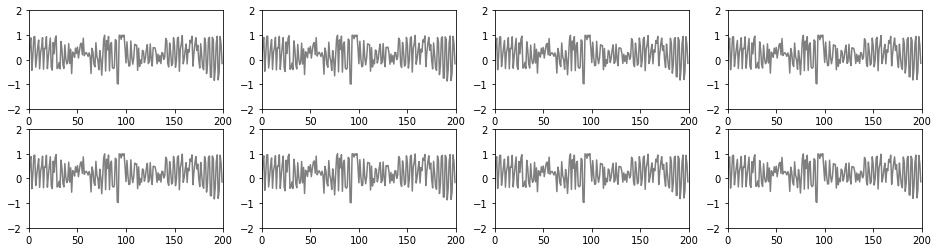

Epoch [2801/5000] -----------------------------------------------------------------------------
G: 7.195720911026001, Dr : 0.002077654644381255, Df : 0.004360868711955845


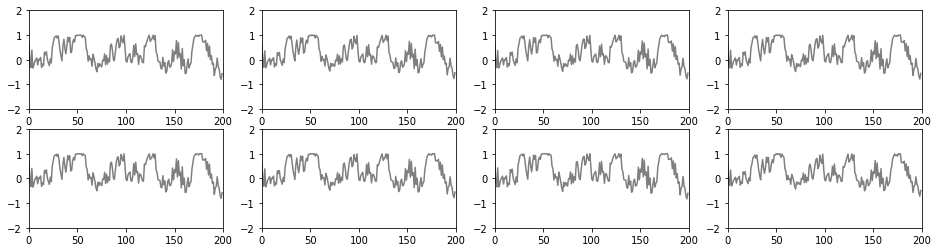

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 7.168037414550781, Dr : 0.003597880247980356, Df : 0.004447958490345627


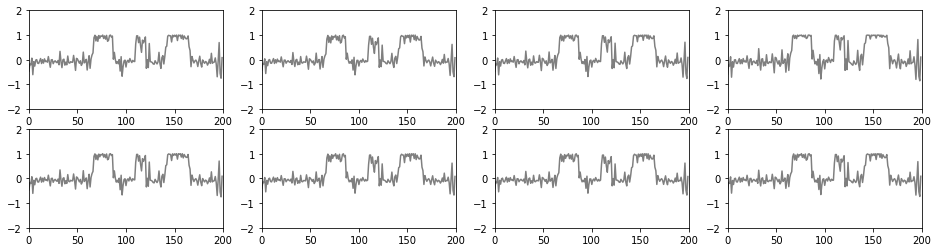

Epoch [3201/5000] -----------------------------------------------------------------------------
G: 8.186616778373718, Dr : 0.0022895030269864947, Df : 0.0019021522311959416


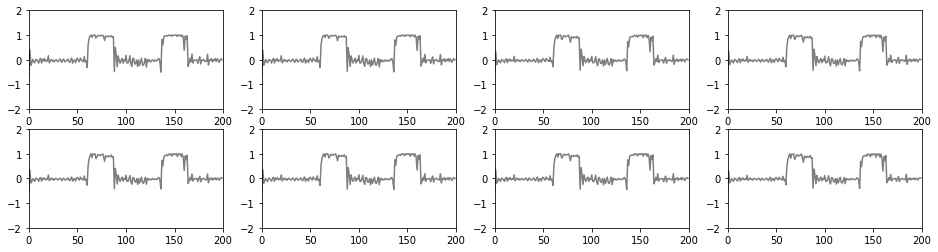

Epoch [3401/5000] -----------------------------------------------------------------------------
G: 9.288983941078186, Dr : 0.0007444246803061105, Df : 0.000779134061303921


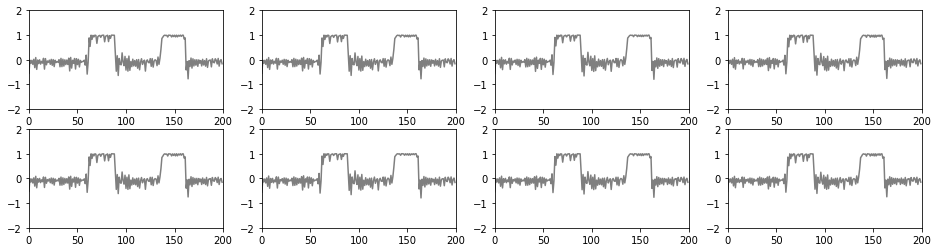

Epoch [3601/5000] -----------------------------------------------------------------------------
G: 10.304783821105957, Dr : 0.0007975080807227641, Df : 0.00033293856540694833


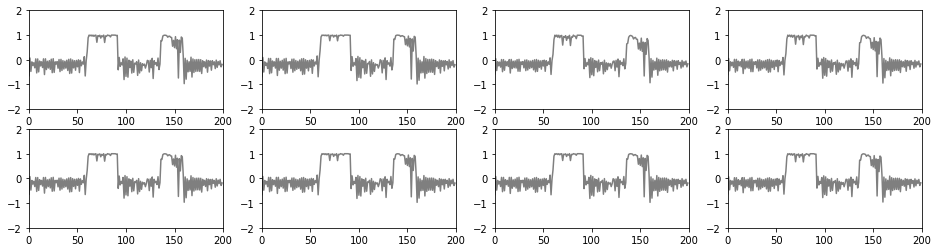

Epoch [3801/5000] -----------------------------------------------------------------------------
G: 5.45537656545639, Dr : 0.020762113970704377, Df : 0.023001092486083508


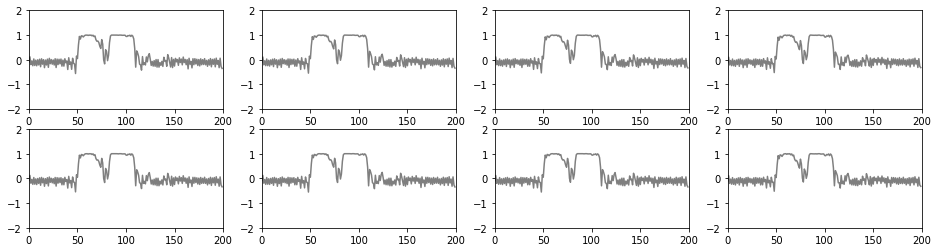

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 6.980530023574829, Dr : 0.009476896550040692, Df : 0.005381056806072593


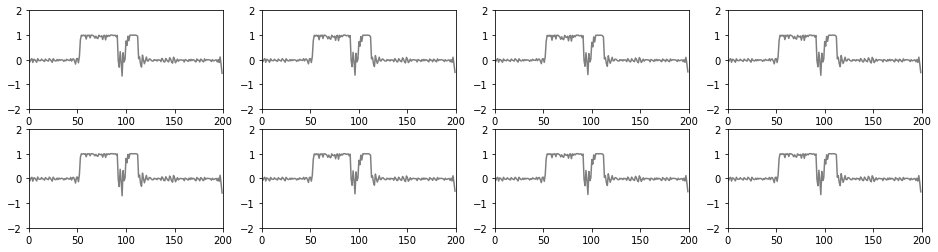

Epoch [4201/5000] -----------------------------------------------------------------------------
G: 7.358556270599365, Dr : 0.0021623641296173446, Df : 0.005129732599016279


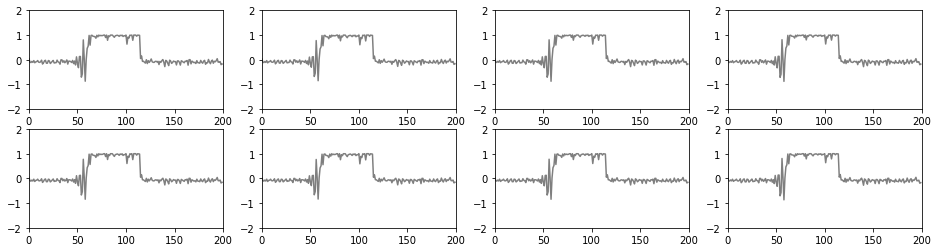

Epoch [4401/5000] -----------------------------------------------------------------------------
G: 7.2135089635849, Dr : 0.00331218124483712, Df : 0.004339089500717819


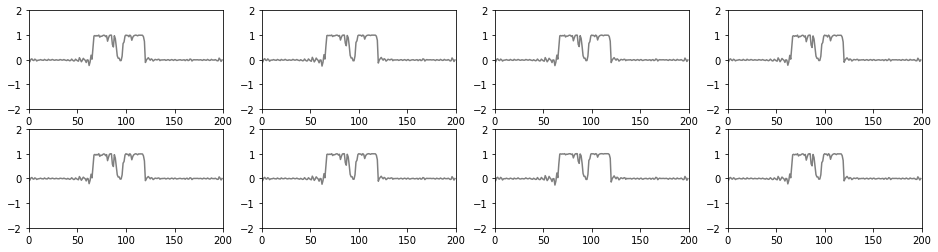

Epoch [4601/5000] -----------------------------------------------------------------------------
G: 7.354658603668213, Dr : 0.014193989176419564, Df : 0.0038417701434809715


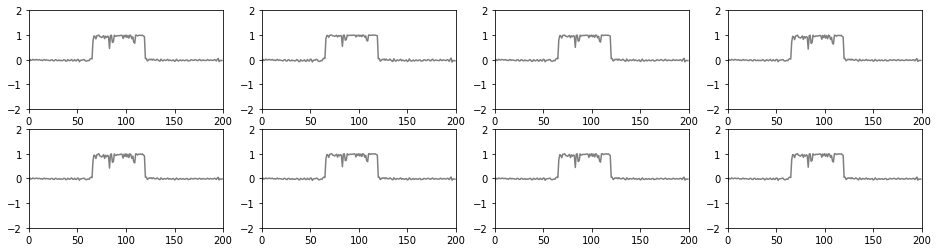

Epoch [4801/5000] -----------------------------------------------------------------------------
G: 7.279627680778503, Dr : 0.005466844031616347, Df : 0.0038278804277069867


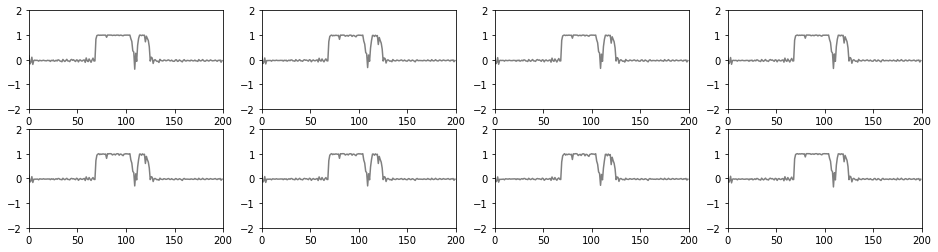

In [ ]:
# Train the model
nb_epoch = 5000

for epoch in range(nb_epoch):
    i = 0

    # if epoch%50 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, x in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((batch_size, 32, 1), device=device)
        with torch.no_grad():
            fake_samples = generator(z)
        pred_fake = discriminator(fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((batch_size, 32, 1), device=device) 

        generated = generator(z)
        classifications = discriminator(generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
    
    if epoch%200 == 0:
      print('Epoch [{}/{}] -----------------------------------------------------------------------------'
          .format(epoch+1, nb_epoch, i, len(train_loader)))
      print('G: {}, Dr : {}, Df : {}'
          .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))
      
      traj_sim = generated.detach().numpy()
      plt.figure(figsize = (16,4))
      for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(traj_sim[i,0,:], c = 'black', alpha = 0.5)
        plt.xlim(0,length)
        plt.ylim(-2,2)

      plt.show()
      plt.close()



In [ ]:
# torch.save(generator, 'basicGAN_cnn_G.pt')
# torch.save(discriminator, 'basicGAN_cnn_D.pt')

# # generator = torch.load('basicGAN_cnn_G.pt')
# # discriminator = torch.load('basicGAN_cnn_D.pt')